# Initialization

In [1]:
%pip install textstat

/bin/zsh: /home/prometheus/anaconda3/envs/llama-env/lib/libncursesw.so.6: no version information available (required by /bin/zsh)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import json
import textstat
from IPython.display import HTML, display
import html, numpy as np
from sentence_transformers import SentenceTransformer
import pandas as pd
#from sklearn.metrics.pairwise import cosine_similarity 


In [2]:
try:
    #DRIVE
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    BASE_FOLDER = 'drive/MyDrive/NLP_proj/'
except:
    #LOCAL
    BASE_FOLDER = './'

In [3]:
GAME_NAMES = ["Ticket to Ride", "Dominion", "Catan", "Power Grid"]
MODELS = ['llama','qwen','gemma']
VERBOSE = False
name_map = {"Ticket to Ride": 'ticket_to_ride', "Dominion":'dominion', "Catan":'catan', "Power Grid":'power_grid_recharged', "7 Wonders":'7_wonders'}

In [5]:
sbert = SentenceTransformer('all-MiniLM-L6-v2')

    
def sliding_windows(words, window_size, stride):
    return [
        (start, end, " ".join(words[start:end])) 
        for start in range(0,len(words)-window_size+stride,stride) 
        if (end := min(start+window_size,len(words)))
    ]
    
def span_score(concept, spans):
    texts = [concept] + [s[2] for s in spans]
    embs = sbert.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    concept_emb = embs[0]
    span_embs = embs[1:]
    return [(start, end, cosine_similarity(concept_emb, e)) for (start, end, _), e in zip(spans, span_embs)]


# The following code has been generated with chatgpt-oss
def cosine_similarity(a,b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-10))
    
def score_to_rgba(score):
    s = max(0.0, min(1.0, score))
    r = 255
    g = int(255*(1-s))
    b = int(255*(1-s))
    a = 0.85 * s
    return f"rgba({r},{g},{b},{a:.2f})"
    
def render_colored_text(tokens, token_scores, title_scores=True):
    lo = 0.0
    hi = 0.70
    norm = [(max(lo, min(hi, s)) - lo)/(hi-lo+1e-12) for s in token_scores]
    parts = []
    for tok, sc, nsc in zip(tokens, token_scores, norm):
        color = score_to_rgba(nsc)
        if nsc > 0.97:
            color = 'rgba(0,255,255,0.85)'
        esc = html.escape(tok)
        title = f" title='score: {sc:.3f}'" if title_scores else ""
        parts.append(f"<span style='background:{color};padding:2px;border-radius:3px;margin:1px;display:inline-block'{title}>{esc}</span>")
    html_doc = "<div style='font-family:system-ui,Segoe UI,Arial;line-height:1.6'>" + " ".join(parts) + "</div>"
    display(HTML(html_doc))

In [6]:
from llama_cpp import Llama, llama_free, llama_free_model
from tqdm import tqdm
#from transformers import AutoTokenizer, pipeline, BitsAndBytesConfig
import requests
from collections import defaultdict
import json
import torch
import os

model = Llama.from_pretrained(repo_id='bartowski/Qwen2.5-7B-Instruct-GGUF', # repository name
                            filename='Qwen2.5-7B-Instruct-Q6_K.gguf', # model file
                            n_gpu_layers=20, # use all GPU layers
                            n_ctx=32768, # context size
                            flash_attn=True, # use flash attention
                            chat_format='qwen', # chat format
                            verbose=VERBOSE,
                            force_download=True,
                            enable_thinking=True)

def generate_message(sys_prompt, usr_prompt):
    return [
        {
                "role": "system",
                "content": sys_prompt,
            },
            {
                "role": "user",
                "content": usr_prompt,
            },
    ]

# Summarize

In [7]:
file_names = name_map.values()
ages=['7','11','16']
iterations = 5
response = {m: {g: {} for g in file_names} for m in MODELS}
for m in MODELS:
    for g in file_names:
        with open(f'{BASE_FOLDER}explain/{m}_{g}.json','r') as f:
            response[m][g] = json.load(f)

## Readability

In [8]:
rows = []
for m in MODELS:
    for g in file_names:
        for a in ages:
            for it in range(iterations):
                text = response[m][g][a][str(it)]
                rows.append({
                    "model": m,
                    "game": g,
                    "age": int(a),
                    "iteration": it,
                    "expected": int(a)-5,
                    "Flesch-Kincaid": textstat.flesch_kincaid_grade(text),
                    "SMOG": textstat.smog_index(text),
                    "Dale-Chall": textstat.dale_chall_readability_score(text),
                })

df = pd.DataFrame(rows)

In [9]:
# EXPLORE MODELS ABILITY TO 
out = df.groupby(["model","age","expected"]).agg({
    "Flesch-Kincaid": "mean",
    "SMOG": "mean",
    "Dale-Chall": "mean"
}).reset_index()

#est = test.pivot_table(index="model", columns= ["age"], values=["Flesch-Kincaid", "SMOG", "Dale-Chall"])
for m in MODELS:
    print(f"{m}\n{'-'*10}")
    print(out[out['model']==m].drop('model', axis=1).to_string(index=False))
    print('\n\n')

llama
----------
 age  expected  Flesch-Kincaid     SMOG  Dale-Chall
   7         2        4.681998 7.716160    8.253474
  11         6        5.757944 8.474957    8.463526
  16        11        6.314246 9.122858    8.987727



qwen
----------
 age  expected  Flesch-Kincaid     SMOG  Dale-Chall
   7         2        4.414505 7.085991    8.130617
  11         6        4.691318 7.584156    8.567904
  16        11        5.351726 8.246739    9.312315



gemma
----------
 age  expected  Flesch-Kincaid     SMOG  Dale-Chall
   7         2        3.678737 6.967014    7.695598
  11         6        4.405593 7.806366    8.011383
  16        11        4.811623 8.084223    8.367832





## Completeness

In [10]:
rule = "Discard Resources on a Roll of 7"
words = response['llama']['catan']['7']['0'].split(' ')
spans = sliding_windows(words, 10, 5)
span_sc = span_score(rule, spans)
w_sc = [0.0]*len(words)
for i,j,sc in span_sc:
    for k in range(i,j):
        w_sc[k] = max(w_sc[k], sc)
render_colored_text(words, w_sc)
print(f'overall score: {max(w_sc)}')

overall score: 0.7364566326141357


In [11]:
window_size = 10
stride = 5
threshold = 0.5
out = {m: {g: {a: 0 for a in ages} for g in file_names} for m in MODELS}



#print(rules)
VERBOSE=True
for m in MODELS:
    for a in ages:
        tot = 0
        for g in file_names:
            with open(f'{BASE_FOLDER}extraction/{g}_final.json','r') as f:
                rules = json.load(f)
            rules = [(int(k),i) for k in rules for i in rules[k]]
            for it in range(iterations):
                words = response[m][g][a][str(it)].split(' ')
                spans = sliding_windows(words, window_size, stride)
                #print([r for (_,r) in rules]+[s[2] for s in spans])
                all_embs = sbert.encode([s[2] for s in spans]+[r for (_,r) in rules], convert_to_numpy=True, show_progress_bar=False)
                embs = all_embs[:len(spans)]
                rule_embs = all_embs[len(spans):]
                for (r_sc ,r),r_emb in zip(rules,rule_embs):
                    sc = [cosine_similarity(r_emb, e) for e in embs]
                    if(VERBOSE):
                        print(f'{m}, {g}, age {a} it {it}\n-------------\nrule: {r} \nscore:{max(sc)}')
                    tot += 4-r_sc
                    if(max(sc) > threshold):
                        out[m][g][a] += 4-r_sc
            out[m][g][a] = out[m][g][a]/tot

llama, ticket_to_ride, age 7 it 0
-------------
rule: Highest total score wins 
score:0.5446373224258423
llama, ticket_to_ride, age 7 it 0
-------------
rule: Score points for claimed routes 
score:0.7278220057487488
llama, ticket_to_ride, age 7 it 0
-------------
rule: Score points for completed tickets 
score:0.6740255951881409
llama, ticket_to_ride, age 7 it 0
-------------
rule: Deduct points for incomplete tickets 
score:0.5734911561012268
llama, ticket_to_ride, age 7 it 0
-------------
rule: Score 10 bonus points for longest continuous path 
score:0.7142810821533203
llama, ticket_to_ride, age 7 it 0
-------------
rule: Tie‑breaker: most completed tickets 
score:0.6259081363677979
llama, ticket_to_ride, age 7 it 0
-------------
rule: Tie‑breaker: longest path card if still tied 
score:0.5698928833007812
llama, ticket_to_ride, age 7 it 0
-------------
rule: Claim a route action 
score:0.6753537058830261
llama, ticket_to_ride, age 7 it 0
-------------
rule: Use matching train cards 

In [12]:
rows = [{'model': m,'game': g,'age':a,'score':out[m][g][a]} for m in MODELS for g in file_names for a in ages]
df = pd.DataFrame(rows)
df.to_csv(f'{BASE_FOLDER}evaluation/completeness.csv', index=False)
df

,model,game,age,score
0,llama,ticket_to_ride,7,0.915385
1,llama,ticket_to_ride,11,0.920513
2,llama,ticket_to_ride,16,0.900000
3,llama,dominion,7,0.357225
4,llama,dominion,11,0.360694
5,llama,dominion,16,0.390751
6,llama,catan,7,0.202299
7,llama,catan,11,0.186207
8,llama,catan,16,0.177778
9,llama,power_grid_recharged,7,0.090554


## Compression

In [13]:
length = {}
for g in file_names:
    with open(f'{BASE_FOLDER}rules/texts/{g}.txt','r') as f:
        length[g] = len(f.read())

rows = [{
    'model': m,
    'game': g,
    'age': a,
    'it': it,
    'relative size': len(response[m][g][a][str(it)])*100/length[g]
}for m in MODELS for g in file_names for a in ages for it in range(iterations)]
df = pd.DataFrame(rows)
df = df.groupby(["model","game"]).agg({
    "relative size": "mean"
}).reset_index()
df

,model,game,relative size
0,gemma,7_wonders,10.133980
1,gemma,catan,11.858901
2,gemma,dominion,6.608242
3,gemma,power_grid_recharged,5.680693
4,gemma,ticket_to_ride,16.381075
5,llama,7_wonders,9.901748
6,llama,catan,12.278925
7,llama,dominion,6.750034
8,llama,power_grid_recharged,6.223590
9,llama,ticket_to_ride,19.590666


# Error Detection

In [14]:
# READ FROM FILE
iterations = 5
file_names = list(name_map.values())
file_names.remove('7_wonders')
models = MODELS + ['gpt-oss']
response = {m: {g: {} for g in file_names} for m in models}
for m in models:
    for g in file_names:
        with open(f'{BASE_FOLDER}error_detection/{m}_{g}.json','r') as f:
            response[m][g] = json.load(f)

In [15]:
# EVALUATION
VERBOSE=True
sys_prompt = """You are a rule‑checking assistant.
Read ANSWER and GROUND TRUTH, narrate whether the explanations refer to the same rule, and conclude with a single wordon the final line:
**CORRECT** -> if the explanation refer to the samer rule
**WRONG** -> if the ANSWER addresses a different issue
**MISS** -> if the ANSWER refer to the rule being consistent but the GROUND TRUTH states differently

### Examples
input:'''
ANSWER -> The Monopoly win condition states that the game ends when all other players have gone bankrupt,leaving a single player with all the assets. However, this rule can be problematic because it assumes that players will continue to take turns until bankruptcy occurs, which may never happen if a player repeatedly lands on “Free Parking” and collects cash without paying any fees. In such a scenario, the game could drag on indefinitely, making the win condition effectively unreachable. A more practical rule might impose a turn limit or a cash‑threshold to declare a winner when the game stalls.
GROUND TRUTH-> The problem is that the first player may reroll the dice any time.
'''

output:'''
The answer does not talk about rerolling the dice
WRONG
'''

---

input:'''
ANSWER ->  After examining the rulebook, I've identified a **gamebreaking** problem: In the first phase of the game rules states that when a player draws a card any other player can choose to draw another card. This could create a scenario where all player are willing to draw until the deck is empty.
GROUND TRUTH -> infinite card draw at the start of the game.
'''
output:'''
the answer and the ground truth adress the card draw in first phases of the game as the problem
CORRECT
'''

---

input:'''
ANSWER -> The rules appear consistent.
GROUND TRUTH -> The rulebook is consistent.
'''
'''
output:'''
both statements refer to the rule being consistent
CORRECT
'''
"""
ground_truth = {
    "ticket_to_ride": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "In the rulebook it is not described how to claim a route",
        "lvl2": "In one section it is stated that during its turn a player may draw up to 2 train cards but on another line states that a player may draw up to 7 cards",
        "lvl3": "The \"a player cannot claim a route unless they have already claimed at least one other contiguous route earlier in the game\" creates a situation where a player may not clame its first route since it is not contiguous to other routes",
        "lvl4": "The rule that allows a player to reveal cards until they reveal a locomotive is unbalanced since it always allow a player to draw 2 locomotives per turn"
    },
    "dominion": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "the buy phase section is missing",
        "lvl2": "the sentence \"After buying a card, a player may **continue to play additional Treasure cards** from their hand to increase their total  for that turn\" this is in direct contrast with a previous statement that does not allow a player to play treasures after the buy phase",
        "lvl3": "the sentence \"You cannot play cards that grant more action as the first action of the turn\" creates a situation where a player can't play card that grant extra action.",
        "lvl4": "the ability to play treasures also from the discard pile is unbalanced since allows player to have an ever increasing amount of gold to spend during their turn removing one of the balancing aspect of the game"
    },
    "7_wonders": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing section explaining the resolution of military conflicts phase",
        "lvl2": "the sentence \"When buying a resource you may use Coins received from a neighbor earlier in the same turn to pay the 2‑Coin cost.\" contradicts a previous rules that states that a player cannot use coin recieved during the same turn to pay for a resource",
        "lvl3": "infinite resolve conflict loop",
        "lvl4": "the rule that allow a player to construct one stage of your Wonder for free is very unbalanced"
    },
    "catan": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing subsection explaining building rules",
        "lvl2": "the sentence \"When you roll a 7, all hexes produce a resource except for the one with the robber.\" is directly in contrast with the rule stating that \"When you roll a 7, hexes do not produce any resources\"",
        "lvl3": "rules state that You can only trade a resource produced this turn by the hex with the robber, however since the hex with the robber does not produce resources this means that trading is not possible",
        "lvl4": "the rule stating that robber steals all resources from all players is very unbalanced since the player rolling a 7 is very likely to win the game"
    },
    "power_grid_recharged": {
        "lvl0": "the rulebook is consistent",
        "lvl1": "missing some steps in phase 5",
        "lvl2": "the sentence \"As explained in the section “The Power Plants”, each power plant may store only the number of resource tokens matching the number of symbols on the card and needs twice that number of tokens to produce electricity\" is contradicted later in the rules",
        "lvl3": "There is no way to reach phase 3 since the \"step 3\" card ir removed at the start of the game",
        "lvl4": "the rule granting a player who does not supply any city the same amount of Elektro as the highest‑earning player is unbalanced since it means that the player spending less resources is also gaining more Elektro than the others"
    }
}

def check_correct(s):
    if 'CORRECT' in s:
        return True
    elif 'WRONG' in s or 'MISS' in s:
        return False
    else:
        return None
verbose = False
rows = []
for m in models:
    print(f"Model: {m}")
    for lvl in range(5):
        res = []
        # construct the answer pair
        answer_pair = []
        for g in file_names:
            for x in response[m][g][f'lvl{lvl}'].values():
                answer_pair.append((x, ground_truth[g][f'lvl{lvl}']))
        # check
        for it, (answer, real) in enumerate(answer_pair):
            usr_prompt = f"ANSWER -> {answer}\nGROUND TRUTH -> {real}"
            retry = 10
            while retry > 0:
                out = model.create_chat_completion(generate_message(sys_prompt, usr_prompt), temperature=0.6)
                out = out['choices'][0]['message']['content']
                last_line = out.splitlines()[-1]
                if 'CORRECT' in last_line or 'WRONG' in last_line or 'MISS' in last_line:
                    retry = 0
                else:
                    retry -= 1
                    if(VERBOSE): print('retry')
            
            # log the response
            rows.append({
                'model' : m,
                'lvl' : lvl,
                'it' : it,
                'model_output' : answer,
                'ground_truth' : real,
                'evaluation' : out,
                'correct' : check_correct(last_line),
                'no_issue' : True if 'Miss' in last_line else False
            })

            if(VERBOSE):
                print(out)
            res.append('CORRECT' if 'CORRECT' in last_line else 'WRONG')
        print(f"lvl{lvl}: {res.count('CORRECT')}/{len(res)}")

df = pd.DataFrame(rows)
df.to_csv(f'{BASE_FOLDER}evaluation/error.csv', index=False)
df

Model: llama
The answer describes a specific rule that creates an advantage for players, whereas the ground truth states that the rulebook is consistent. These do not refer to the same issue.

WRONG
The answer discusses an issue with the rulebook, specifically a rule that allows drawing two locomotives in a single turn, which could give a player an unfair advantage. The ground truth, however, states that the rulebook is consistent, implying no such issue exists.

WRONG
The answer discusses an inconsistency in the rulebook regarding the handling of a player's depleted train stock, while the ground truth states that the rulebook is consistent. These do not refer to the same rule.

WRONG
The answer describes a potential rule loophole that could give an unfair advantage, while the ground truth states that the rulebook is consistent. These refer to different issues.

WRONG
The answer highlights an ambiguity in the rulebook, while the ground truth states that the rulebook is consistent. Thes

,model,lvl,it,model_output,ground_truth,evaluation,correct,no_issue
0,llama,0,0,"After scanning the rulebook, I've identified a...",the rulebook is consistent,The answer describes a specific rule that crea...,False,False
1,llama,0,1,"After carefully reading the rulebook, I've ide...",the rulebook is consistent,The answer discusses an issue with the ruleboo...,False,False
2,llama,0,2,"After thoroughly examining the rulebook, I've ...",the rulebook is consistent,The answer discusses an inconsistency in the r...,False,False
3,llama,0,3,"After examining the rulebook, I have identifie...",the rulebook is consistent,The answer describes a potential rule loophole...,False,False
4,llama,0,4,"After carefully reviewing the rulebook, I've i...",the rulebook is consistent,The answer highlights an ambiguity in the rule...,False,False
...,...,...,...,...,...,...,...,...
395,gpt-oss,4,15,**Most impactful problem – contradictory rule ...,the rule granting a player who does not supply...,The answer discusses a problem with a conflict...,False,False
396,gpt-oss,4,16,**Most impactful problem – contradictory end‑o...,the rule granting a player who does not supply...,The answer discusses contradictions in the end...,False,False
397,gpt-oss,4,17,**Most impactful problem – contradictory descr...,the rule granting a player who does not supply...,The answer addresses an issue with the resourc...,False,False
398,gpt-oss,4,18,**Most impactful problem – contradictory descr...,the rule granting a player who does not supply...,The answer discusses an inconsistency in the r...,False,False


In [16]:
l_df = df.groupby(["model","lvl"]).agg({
    "correct": "sum"
}).reset_index()
l_df

,model,lvl,correct
0,gemma,0,0
1,gemma,1,0
2,gemma,2,0
3,gemma,3,0
4,gemma,4,0
5,gpt-oss,0,1
6,gpt-oss,1,3
7,gpt-oss,2,13
8,gpt-oss,3,11
9,gpt-oss,4,10


['gemma', 'gpt-oss', 'llama', 'qwen']
[[0, 1, 0, 10], [0, 3, 1, 0], [0, 13, 0, 0], [0, 11, 0, 0], [0, 10, 0, 0]]


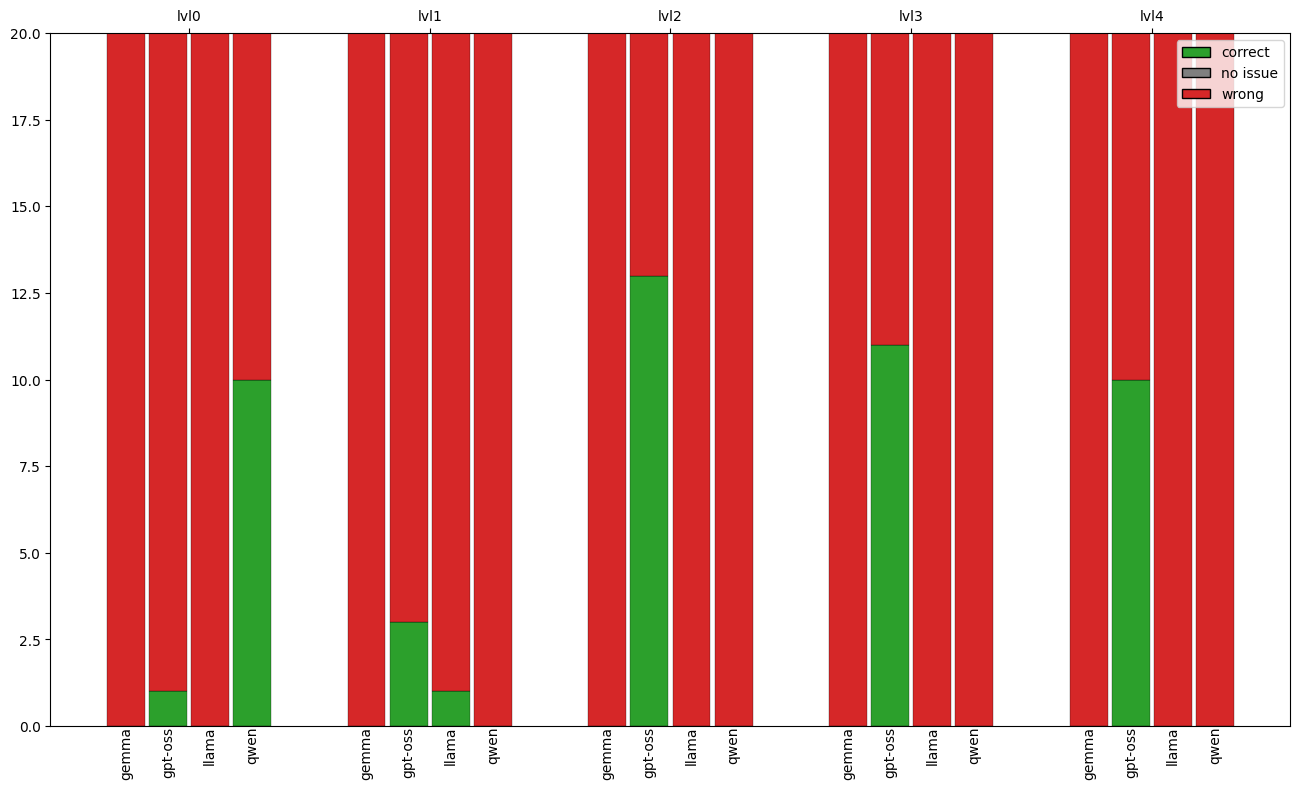

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# code partially generated using gpt-oss

 #np.array([[m, m+'_all'] for m in MODELS]).flatten()
level_names = ['lvl0','lvl1','lvl2','lvl3','lvl4']
l_df.sort_values(by='model')
model_names = list(l_df[l_df['lvl']==0]['model'])
levels = []
for l in range(5):
    levels.append(list(l_df[l_df['lvl']==l]['correct']))
print(model_names)
print(levels)
n_levels = len(level_names)
n_models = len(models)

proc_levels = []
for lvl in levels:
    proc_levels.append({
        'correct': np.array(lvl),
        'no_issue': np.array([0]*len(lvl)),
        'wrong': np.array([20-l for l in lvl])
    })


group_width = 0.7
bar_width = group_width / n_models
x = np.arange(n_levels)

fig, ax = plt.subplots(figsize=(16,9))


offsets = (np.arange(n_models) - (n_models-1)/2) * bar_width

colors = {'correct':'#2ca02c', 'no_issue':'#7f7f7f', 'wrong':'#d62728'}

for m_idx in range(n_models):
    correct_vals = np.array([proc_levels[L]['correct'][m_idx] for L in range(n_levels)])
    no_issue_vals = np.array([proc_levels[L]['no_issue'][m_idx] for L in range(n_levels)])
    wrong_vals   = np.array([proc_levels[L]['wrong'][m_idx] for L in range(n_levels)])

    bar_positions = x + offsets[m_idx]
    p1 = ax.bar(bar_positions, correct_vals, width=bar_width*0.90, color=colors['correct'], edgecolor='k', linewidth=0.2)
    p2 = ax.bar(bar_positions, no_issue_vals, width=bar_width*0.90, bottom=correct_vals, color=colors['no_issue'], edgecolor='k', linewidth=0.2)
    p3 = ax.bar(bar_positions, wrong_vals, width=bar_width*0.90, bottom=correct_vals+no_issue_vals, color=colors['wrong'], edgecolor='k', linewidth=0.2)


ax.set_ylim(0,20)
ax.set_xticks(x)
ax.set_xticklabels(level_names)
ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors['correct'], edgecolor='k', label='correct'),
                  Patch(facecolor=colors['no_issue'], edgecolor='k', label='no issue'),
                  Patch(facecolor=colors['wrong'], edgecolor='k', label='wrong')]
ax.legend(handles=legend_handles, loc='upper right')


for L in range(n_levels):
    for m_idx in range(n_models):
        xpos = x[L] + offsets[m_idx]
        # etichetta compatta con rotazione 90 per non sovrapporre
        ax.text(xpos, 0, model_names[m_idx], ha='center', va='top', rotation=90)
plt.savefig(f'{BASE_FOLDER}img/error.pdf')
plt.show()


# Estimation

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")

print("Path to dataset files:", path)

Path to dataset files: /home/prometheus/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4


In [5]:
df = pd.read_csv(path+"/games.csv")
m_df = pd.read_csv(path+"/mechanics.csv")

## READ FILE

In [6]:
import re
iterations = 10
file_names = list(name_map.values())
file_names.remove('7_wonders')
parameters = ['complexity', 'mechanics', 'player', 'duration']
regex = {'mechanics': r"(?i)^.*\bmechanics\s*:\s*(\[.*\])\s*$",
         'complexity': r'(?i)^.*\bcomplexity.*:\s*([1-5]\.\d)',
         'player': r'(?i)^.*\bplayer.*:\s*(\d+).*',
         'duration': r'(?i)^.*\bduration.*:\s*(\d+)(?:-(\d+))?'

}
def retrieve_estimate():
    param_all = [p+'_all' for p in parameters]
    est = {g:{m:{p: [] for p in parameters + param_all} for m in MODELS}for g in file_names}
    for g in file_names:
        for m in MODELS:
            with open(f'{BASE_FOLDER}estimation/{m}_{g}.json','r') as f:
                raw = json.load(f)
            all_dic = {p:[] for p in parameters}
            for it in range(10):
                js = json.loads(raw['all'][str(it)])
                for p in parameters:
                    ## ALL
                    p2 = p if p != 'player' else 'optimal player count'
                    est[g][m][p+'_all'].append(js['answer'][p2])
                    ## SING
                    match = re.match(regex[p],
                                     raw[p][str(it)].rstrip().splitlines()[-1])
                    if not match:
                        print('the following line does not match:')
                        print(raw[p][str(it)].rstrip().splitlines()[-1])
                    else:
                        #TODO for ranges use the mean of the two matches
                        est[g][m][p].append(match.group(1))
    return est

#print(retrieve_estimate())

In [17]:
from matplotlib import pyplot as plt
import seaborn as sns
GAME_NAMES = ["Ticket to Ride", "Dominion", "Catan", "Power Grid"]
# tmp fix find a better solution

gt = {name_map[g]: {
         'complexity': float(df.loc[df['Name'] == g, 'GameWeight'].values[0]),
         'duration': float(df.loc[df['Name'] == g, 'MfgPlaytime'].values[0]),
         'player': float(df.loc[df['Name'] == g, 'BestPlayers'].values[0])
         } for g in GAME_NAMES}

def print_param_est(est,g,p):
    plt.title(g)
    for m in MODELS:
        plt.axhline(y=gt[g][p], color = 'r')
        sns.swarmplot(x=[m]*len(est[g][m][p]), y=map(float,est[g][m][p]))
        sns.swarmplot(x=[m+'_all']*len(est[g][m][p+'_all']), y=map(float,est[g][m][p+'_all']))
    plt.savefig(f'{BASE_FOLDER}img/{g}{p}_swarm.pdf')
    plt.show()

def mean_error(est,m,p,t=''):
    error = [gt[name_map[g]][p]-float(x) for g in GAME_NAMES for x in est[name_map[g]][m][p+t]]
    return sum(error)/len(error)
 
def mean_abs_error(est,m,p,t=''):
    error = [abs(gt[name_map[g]][p]-float(x)) for g in GAME_NAMES for x in est[name_map[g]][m][p+t]]
    return sum(error)/len(error)       
    
est = retrieve_estimate()
print(mean_error(est,'complexity'))

the following line does not match:
Based on my analysis, I recommend the optimal player count for Ticket to Ride to be 3-4 players. This player count offers a good balance between competition, social interaction, and gameplay complexity. With 3-4 players, the game is engaging, challenging, and fun, and players can enjoy a well-rounded experience.
the following line does not match:
Based on the analysis, I recommend the **optimal player count** to be **4 players**. This player count provides a good balance between competition, interaction, and play time. The game remains relatively balanced, and players have enough opportunities to achieve their goals without feeling overwhelmed.
the following line does not match:
While 2-player games can be enjoyable, they may become too straightforward, with less strategic depth. Games with 5 players may become too chaotic, with too much competition and blocking.
the following line does not match:
**Optimal player count:** 3-4 players
the following li

TypeError: mean_error() missing 1 required positional argument: 'p'

## COMPLEXITY

llama
mean error: -1.6923500000000005 
mean abs error: 1.6923500000000005
mean error all: -1.2323500000000007 
mean abs error all: 1.2323500000000007
qwen
mean error: -1.22485 
mean abs error: 1.22485
mean error all: -1.0548500000000005 
mean abs error all: 1.0649150000000003
gemma
mean error: -1.0923500000000004 
mean abs error: 1.0923500000000004
mean error all: -1.0573500000000005 
mean abs error all: 1.0573500000000005


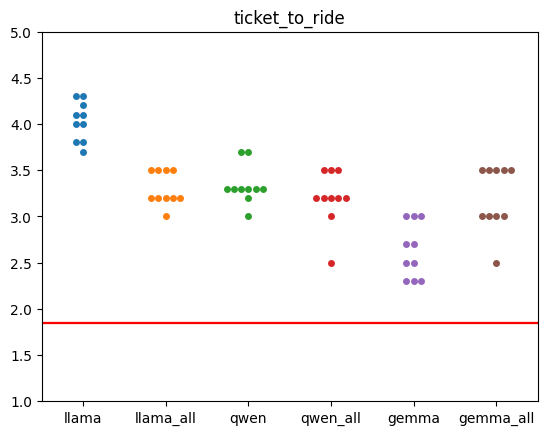

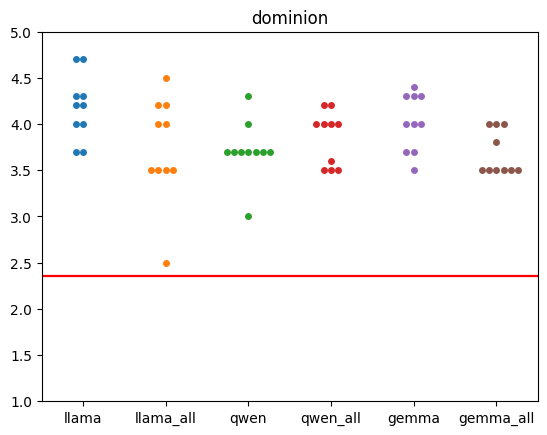

/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


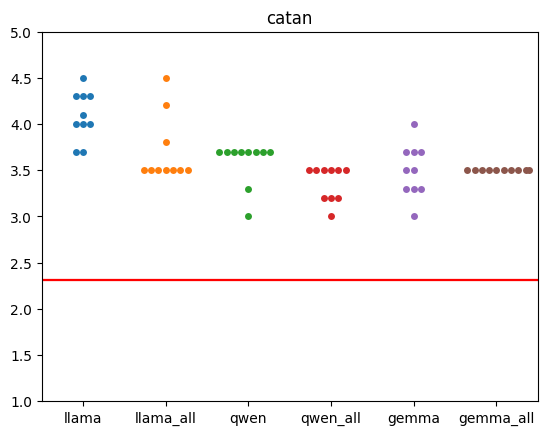

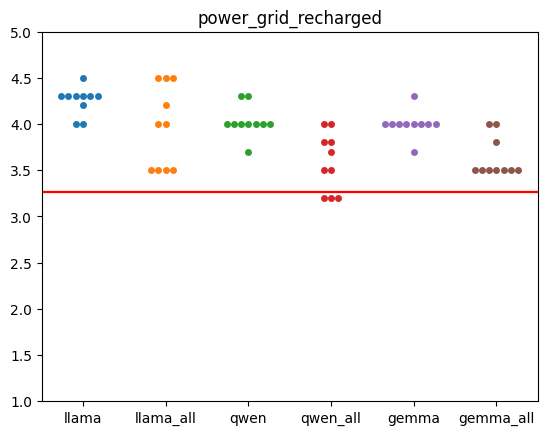

In [19]:
p = 'complexity'
for m in MODELS:
    print(m)
    print(f"mean error: {mean_error(est,m,p)} \nmean abs error: {mean_abs_error(est,m,p)}")
    print(f"mean error all: {mean_error(est,m,p,'_all')} \nmean abs error all: {mean_abs_error(est,m,p,'_all')}")
for g in file_names:
    plt.ylim(1,5)
    print_param_est(est,g,p)

## OPTIMAL PLAYER COUNT

llama
mean error: 0.4166666666666667 
mean abs error: 0.4166666666666667
mean error all: 1.05 
mean abs error all: 1.05
qwen
mean error: -0.15 
mean abs error: 0.3
mean error all: 0.425 
mean abs error all: 0.575
gemma
mean error: 0.325 
mean abs error: 0.325
mean error all: 0.475 
mean abs error all: 0.475


/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


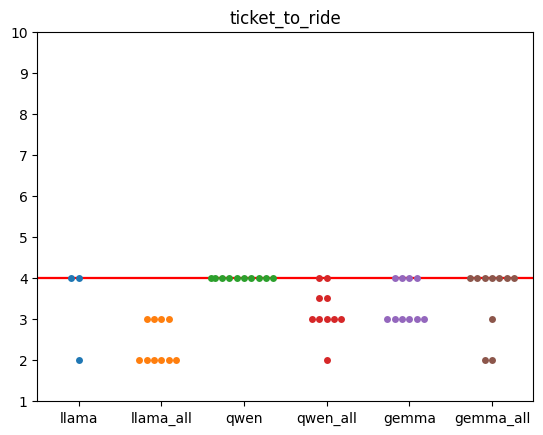

/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


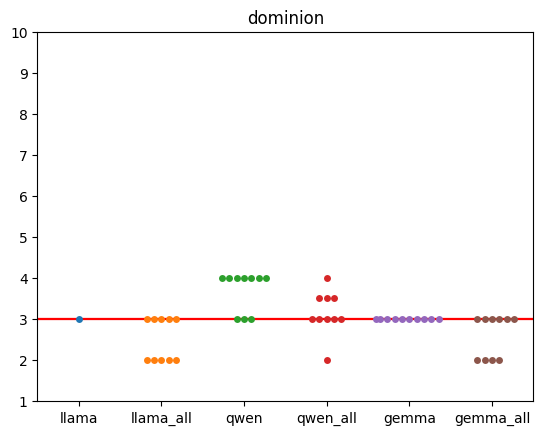

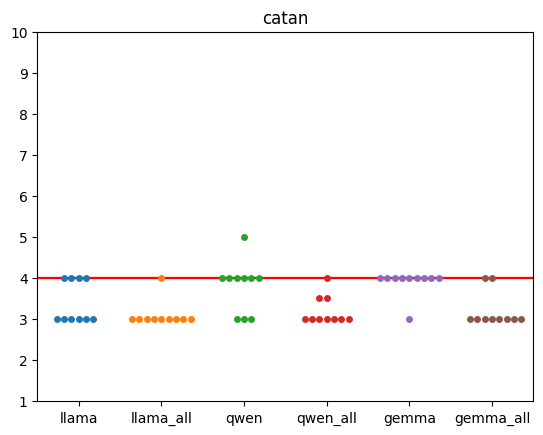

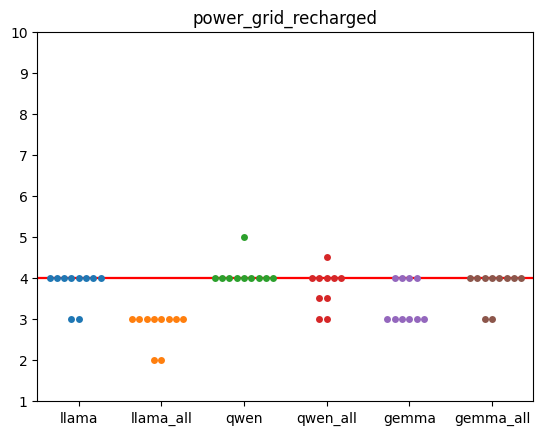

In [20]:
p = 'player'
for m in MODELS:
    print(m)
    print(f"mean error: {mean_error(est,m,p)} \nmean abs error: {mean_abs_error(est,m,p)}")
    print(f"mean error all: {mean_error(est,m,p,'_all')} \nmean abs error all: {mean_abs_error(est,m,p,'_all')}")

for g in file_names:
    plt.ylim(1,10)
    print_param_est(est,g,p)

## DURATION

llama
mean error: 6.75 
mean abs error: 29.25
mean error all: 17.25 
mean abs error all: 33.0
qwen
mean error: 15.15 
mean abs error: 32.4
mean error all: 24.375 
mean abs error all: 33.125
gemma
mean error: 20.375 
mean abs error: 31.875
mean error all: 29.125 
mean abs error all: 35.875


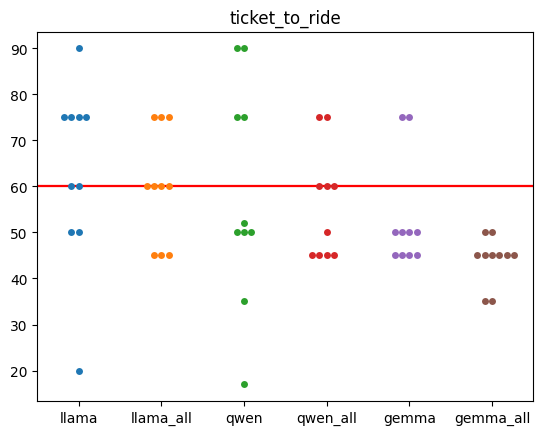

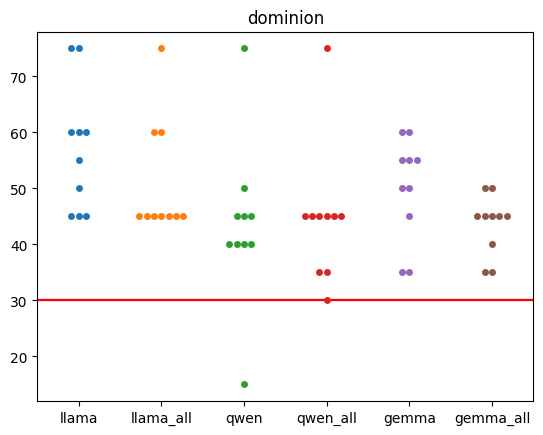

/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/prometheus/anaconda3/envs/llama-env/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


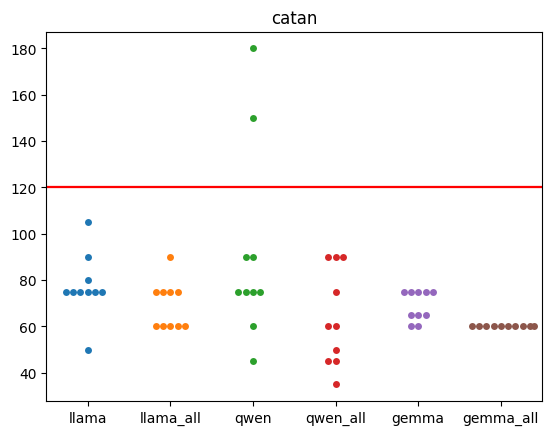

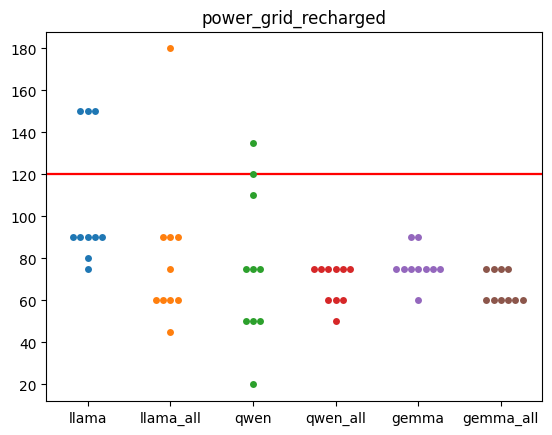

In [21]:
p = 'duration'
for m in MODELS:
    print(m)
    print(f"mean error: {mean_error(est,m,p)} \nmean abs error: {mean_abs_error(est,m,p)}")
    print(f"mean error all: {mean_error(est,m,p,'_all')} \nmean abs error all: {mean_abs_error(est,m,p,'_all')}")

for g in file_names:
    print_param_est(est,g,p)

## MECHANICS

In [69]:
def loosely_in(a,b):
    sim = [cosine_similarity(*sbert.encode([a,e], convert_to_numpy=True, show_progress_bar=False)) for e in b]
    return max(sim) > 0.4
rows = []
real_positives = {g:{m: 0 for m in MODELS} for g in GAME_NAMES}
pred_positives = {g:{m: 0 for m in MODELS} for g in GAME_NAMES}

for g in GAME_NAMES:
    for m in MODELS:
        for it in range(len(est[name_map[g]][m]['mechanics'])):
            estimate = est[name_map[g]][m]['mechanics'][it]
            if type(estimate) == type('text'):
                estimate = estimate[1:-1].split(', ')
            pred_positives[g][m] += len(estimate)
            bggid = df.loc[df['Name'] == g, 'BGGId'].values[0]
            gt = m_df[m_df['BGGId'] == bggid]
            gt = gt.columns[gt.iloc[0]==1].tolist()
            real_positives[g][m] += len(gt)
            #print(gt)
            for mechanic in estimate:
                #print(f'{mechanic} loosely_in{loosely_in(mechanic,gt)}, exactly in: {mechanic in gt}')
                rows.append({
                    'game': g,
                    'model': m,
                    'iteration': it,
                    'mechanic': mechanic,
                    'exactly_in': True if mechanic in gt else False,
                    'loosely_in': loosely_in(mechanic, gt),})
tdf = pd.DataFrame(rows)
print(tdf)
# MEAN GAME PRECISION AND RECALL
# true positives

tdf = tdf.groupby(["model","game"]).agg({ "exactly_in": "sum", "loosely_in": "sum",}).reset_index()
# precision
tdf['exact_precision'] = tdf.apply(lambda row: row.exactly_in/pred_positives[row.game][row.model] , axis=1)
tdf['loose_precision'] = tdf.apply(lambda row: row.loosely_in/pred_positives[row.game][row.model], axis=1)
# recall
tdf['exact_recall'] = tdf.apply(lambda row: row.exactly_in/real_positives[row.game][row.model], axis=1)
tdf['loose_recall'] = tdf.apply(lambda row: row.loosely_in/real_positives[row.game][row.model], axis=1)
tdf = (
    tdf.groupby('model')
       .agg(mean_exact_precision=('exact_precision', 'mean'),
            mean_loose_precision=('loose_precision', 'mean'),
            mean_exact_recall=('exact_recall', 'mean'),
            mean_loose_recall=('loose_recall', 'mean'))
       .reset_index()
)
print(tdf)

                game  model  iteration                       mechanic  \
0     Ticket to Ride  llama          0            Resource Management   
1     Ticket to Ride  llama          0                 Route Building   
2     Ticket to Ride  llama          0                Hand Management   
3     Ticket to Ride  llama          0              Ticket Collection   
4     Ticket to Ride  llama          0                        Scoring   
...              ...    ...        ...                            ...   
1181      Power Grid  gemma          9    Simulating Action Selection   
1182      Power Grid  gemma          9         Variable Player Powers   
1183      Power Grid  gemma          9  Card Play Conflict Resolution   
1184      Power Grid  gemma          9                 Track Movement   
1185      Power Grid  gemma          9             Player Elimination   

      exactly_in  loosely_in  
0          False       False  
1          False        True  
2           True        True  